## Linear Regression from Scratch 

Linear Regression is a practical implementation of the Linear Regression algorithm using only Python and NumPy. This notebook demonstrates how predictions are generated, how model performance is measured using the Mean Squared Error (MSE) cost function, and how Gradient Descent optimizes the model parameters. The project focuses on understanding the mathematical concepts behind Linear Regression rather than relying on built-in machine learning libraries. By implementing each component step by step, we gain a deeper understanding of supervised learning, optimization, and predictive modeling.

In [55]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns   
# Set default styles for our plots

sns.set_theme()

## 1. Data Preparation

In [56]:
X = np.array([1,3,4,6,7]) # Input feature: years of experience 
y = np.array([20,35,49,65,76])  # Target value: salary in k dollar 

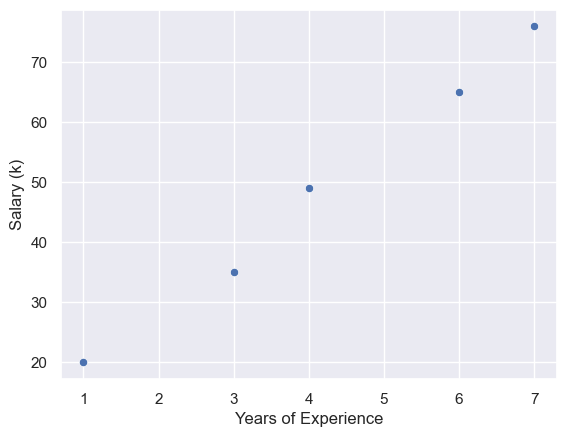

In [78]:
# Visualize the relationship between experience and salary
sns.scatterplot(x=X, y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.show()


## 2. Prediction Function

In [58]:
def prediction_maker (X,y,w,b):
    m = X.shape[0]
    pred_list = np.zeros(m,)

    for i in range(m):
        pred_list[i] = w * X[i] + b
     
    return pred_list    


[0. 0. 0. 0. 0.]


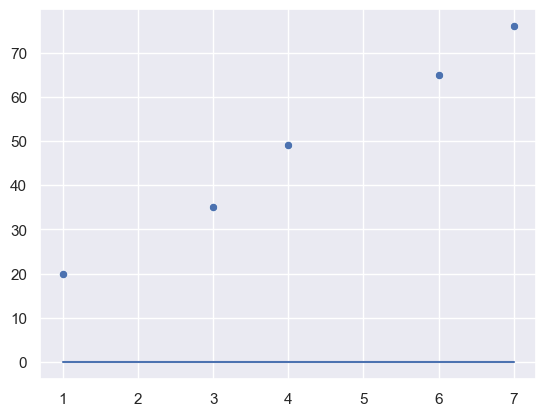

In [59]:
predictions = prediction_maker(X,y,0,0)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)



[1. 3. 4. 6. 7.]


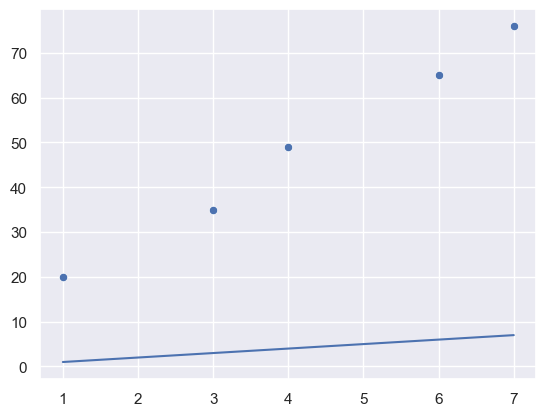

In [60]:
predictions = prediction_maker(X,y,w =1,b=0)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

plt.show()

[ 9. 19. 24. 34. 39.]


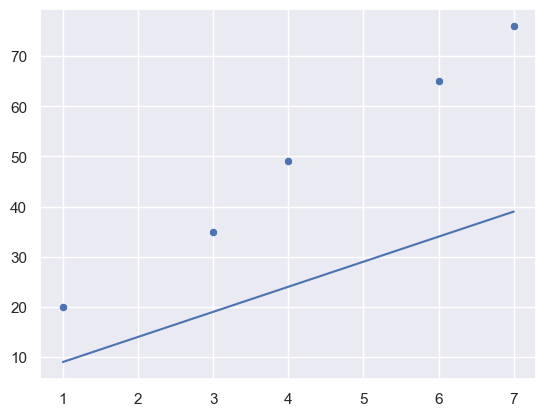

In [61]:
predictions = prediction_maker(X,y,w =5,b=4)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.show()

[15. 35. 45. 65. 75.]


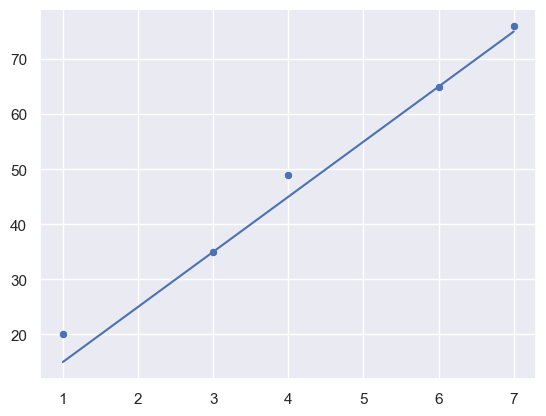

In [62]:
predictions = prediction_maker(X,y,w =10,b=5)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

plt.show()

## 3. Cost Function

In [63]:
def compute_cost(X,y,w,b):
    m = X.shape[0]  # number of datapoint 
    cost = 0.0

    for i in range(m):
        prediction= w * X[i] + b
        error = prediction- y[i]
        error_squared = error ** 2
        cost = cost + error_squared  

    cost = cost / m 
    return cost
        

## 4. Visualizing the Cost

[0. 0. 0. 0. 0.]


Text(0.5, 1.0, 'Cost : 2805.4,for w =0.0 and b = 0.0 ')

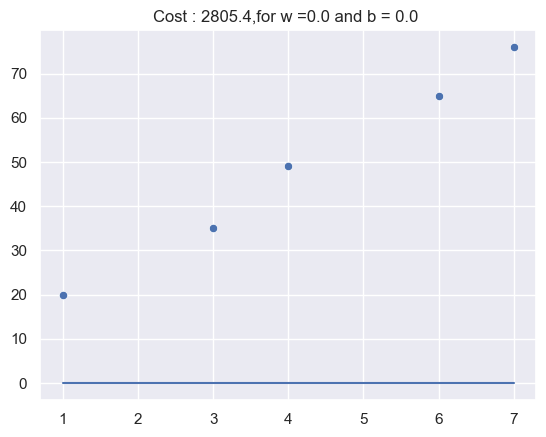

In [64]:

w = 0.0
b = 0.0 
predictions = prediction_maker(X,y,w =w,b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost : {compute_cost(X,y,w=w,b=b)},for w ={w} and b = {b} ")




[1. 3. 4. 6. 7.]


Text(0.5, 1.0, 'Cost : 2330.4,for w =1.0 and b = 0.0 ')

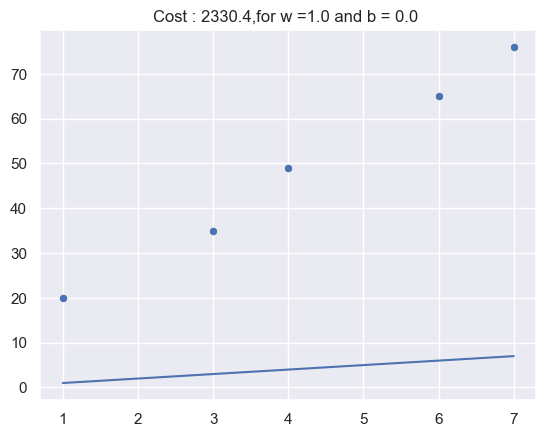

In [65]:

w = 1.0
b = 0.0 
predictions = prediction_maker(X,y,w = w,b = b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost : {compute_cost(X,y,w=w,b=b)},for w ={w} and b = {b} ")



[ 5. 11. 14. 20. 23.]


Text(0.5, 1.0, 'Cost : 1372.0,for w =3.0 and b = 2.0 ')

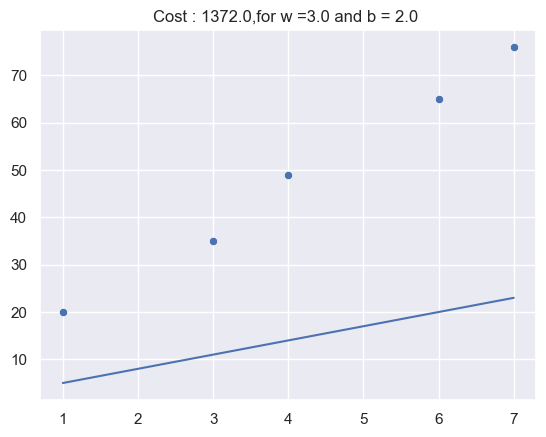

In [66]:

w = 3.0
b = 2.0 
predictions = prediction_maker(X,y,w = w,b = b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost : {compute_cost(X,y,w = w,b = b)},for w = {w} and b = {b} ")




[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost : 8.4,for w =10.0 and b = 5.0 ')

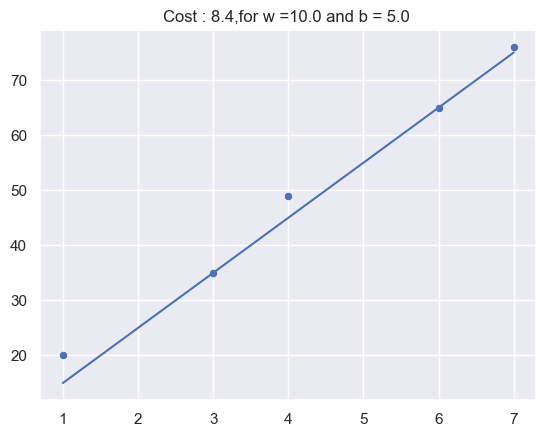

In [67]:

w = 10.0
b = 5.0 
predictions = prediction_maker(X,y,w = w,b = b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost : {compute_cost(X,y,w=w,b=b)},for w ={w} and b = {b} ")



Text(0, 0.5, 'Cost -> J(w)')

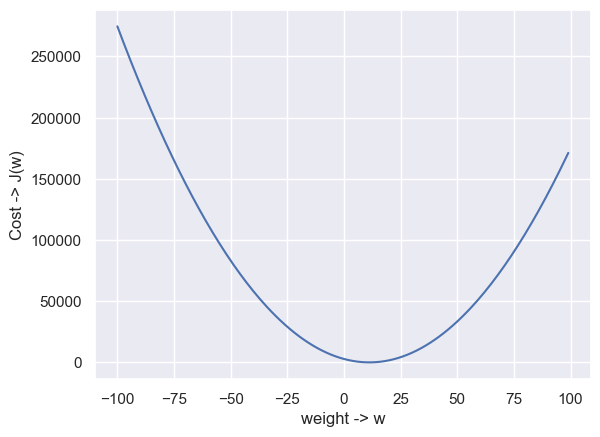

In [68]:
weight = []
cost = []

# w --> -100 -> 1
for i in range(-100, 100): 
    cost_i = compute_cost(X,y,w=i,b=0)
    weight.append(i)
    cost.append(cost_i)

plt.plot(weight,cost) 
plt.xlabel("weight -> w")
plt.ylabel("Cost -> J(w)")


## 5.Gradient Descent

In [69]:
def calculate_gradient(X, y, w, b):
  """Computes the gradient (direction to move) for w and b"""
  m = X.shape[0]
  dj_dw = 0.0 # Change needed for weight
  dj_db = 0.0 # Change needed for bias

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    # Multiply error by X[i] for the weight gradient
    dj_dw = dj_dw + (error * X[i])
    # The bias gradient is just the sum of errors
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m

In [70]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """ Automates the tuning of w and b to minimize cost """
  w = w_input
  b = b_input
  cost_memory = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memory.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")

  return w, b, cost_memory, iteration

In [71]:
# Run gradient descent and store the results in w_final and b_final
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=0, b_input=0, max_iter=6500, alpha=0.01)

Iteration 0: Cost 1669.0136, w: 2.4860, b: 0.4900
Iteration 100: Cost 10.4492, w: 10.5597, b: 3.4301
Iteration 200: Cost 7.9043, w: 10.3485, b: 4.5368
Iteration 300: Cost 6.1931, w: 10.1752, b: 5.4444
Iteration 400: Cost 5.0425, w: 10.0332, b: 6.1886
Iteration 500: Cost 4.2688, w: 9.9167, b: 6.7988
Iteration 600: Cost 3.7486, w: 9.8211, b: 7.2992
Iteration 700: Cost 3.3987, w: 9.7428, b: 7.7096
Iteration 800: Cost 3.1635, w: 9.6786, b: 8.0460
Iteration 900: Cost 3.0054, w: 9.6259, b: 8.3220
Iteration 1000: Cost 2.8990, w: 9.5827, b: 8.5482
Iteration 1100: Cost 2.8275, w: 9.5473, b: 8.7337
Iteration 1200: Cost 2.7794, w: 9.5183, b: 8.8859
Iteration 1300: Cost 2.7471, w: 9.4945, b: 9.0106
Iteration 1400: Cost 2.7253, w: 9.4749, b: 9.1129
Iteration 1500: Cost 2.7107, w: 9.4589, b: 9.1968
Iteration 1600: Cost 2.7009, w: 9.4458, b: 9.2656
Iteration 1700: Cost 2.6943, w: 9.4350, b: 9.3220
Iteration 1800: Cost 2.6898, w: 9.4262, b: 9.3682
Iteration 1900: Cost 2.6868, w: 9.4189, b: 9.4062
Iter

## Final Result and Prediction

Optimized w: 9.3860, b: 9.5789


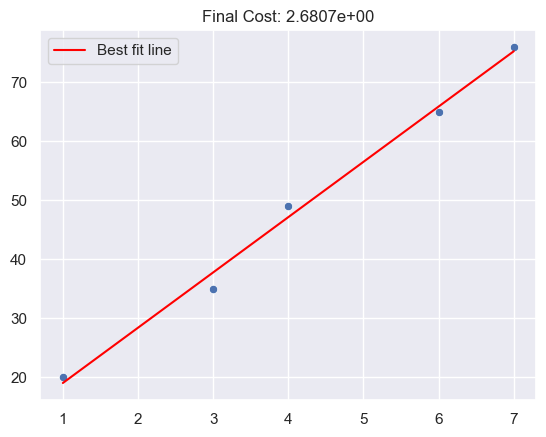

In [72]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Get final predictions based on optimized parameters
final_preds = prediction_maker(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

In [73]:
# Example: Predicting salary for someone with 2 years of experience
x_new = 2

# Using the formula f(x) = wx + b with our final calculated parameters
prediction = w_final * x_new + b_final
print(f"Predicted salary for {x_new} years of experience: {prediction:0.2f}k")

Predicted salary for 2 years of experience: 28.35k


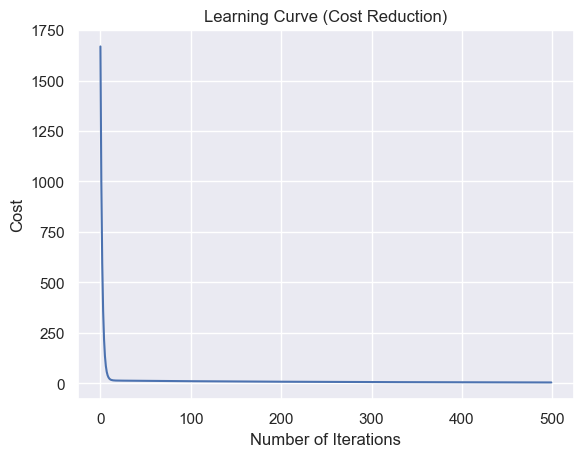

In [74]:
plt.plot(iter_list[:500], cost_memo[:500])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")

plt.show()

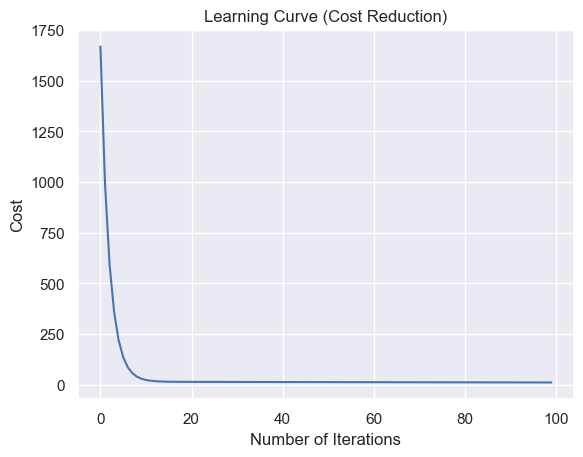

In [75]:
plt.plot(iter_list[:100], cost_memo[:100])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()

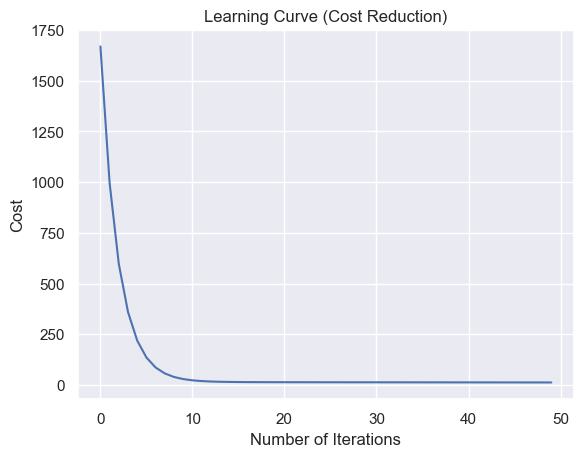

In [76]:
plt.plot(iter_list[:50], cost_memo[:50])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()

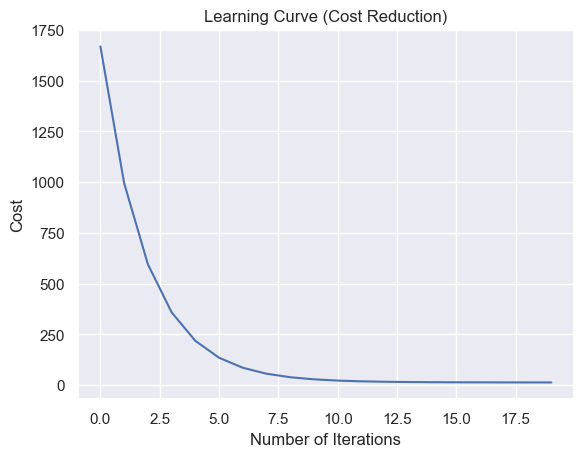

In [77]:
# Plot the cost over the first 20 iterations to see it dropping
plt.plot(iter_list[:20], cost_memo[:20])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()